## Error Estimation

How to estimate error for non-Gaussian distribution

In [3]:
import sys,os
import pandas as pd
import numpy as np

from scipy import stats
import math

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

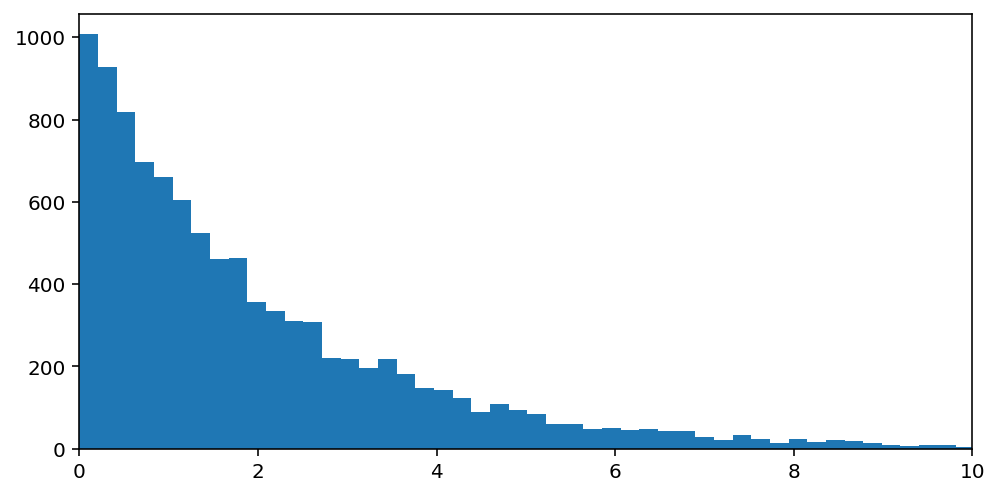

In [4]:
# Generate exponentially-distributed data
yy = np.random.exponential(scale=2.0, size=10**4)

plt.rcParams["figure.figsize"] = (8, 4) # (width, height)
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(yy,bins=100)
ax.set_xlim(left=0,right=10)
plt.show();

In [5]:
# Calculate mean and standard error
mean1 = yy.sum()/len(yy)
mean2 = np.mean(yy)
std1  = np.sqrt(np.square(np.subtract(yy,mean1)).mean())
std2  = np.std(yy)
print(f"mean1 = {mean1:.4f}")
print(f"mean2 = {mean2:.4f}")
print(f"std1  = {std1:.4f}")
print(f"std2  = {std2:.4f}")

mean1 = 1.9826
mean2 = 1.9826
std1  = 1.9976
std2  = 1.9976


np.sqrt(N2)*std_means = 2.0978
np.sqrt(N2)*std_means = 2.0069
np.sqrt(N2)*std_means = 2.0808
np.sqrt(N2)*std_means = 1.9715
np.sqrt(N2)*std_means = 2.0300
np.sqrt(N2)*std_means = 2.0722
np.sqrt(N2)*std_means = 1.9835
np.sqrt(N2)*std_means = 1.9503
np.sqrt(N2)*std_means = 1.9331
np.sqrt(N2)*std_means = 1.9780


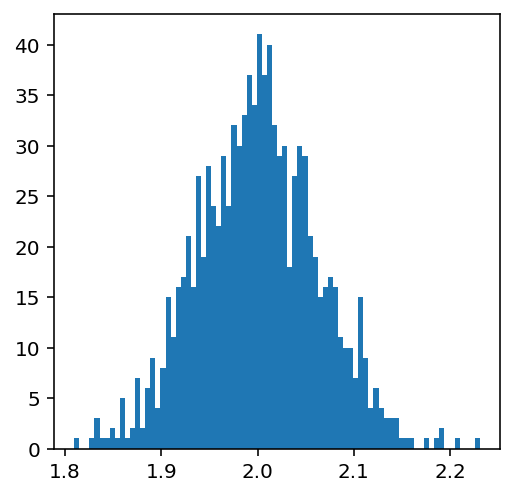

In [6]:
# Using CLT to convert to Normal distribution to estimate the error
# Split N points into N1 groups of N2 points
# Calculate mean for each group
# Estimate error of distribution of means
# Multiply by sqrt(group_size)

N1 = 1000   # N groups
N2 = 1000   # N points in each group
N  = N1*N2 # N = total number of points

for trial in range(10):
    means = []
    for ii in range(N1):
        yy = np.random.exponential(scale=2.0, size=N2)
        means.append(np.mean(yy))

    std_means = np.std(means)
    print(f"np.sqrt(N2)*std_means = {np.sqrt(N2)*std_means:.4f}")
    
plt.rcParams["figure.figsize"] = (4, 4) # (width, height)
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(means, bins=80)
plt.show();

np.sqrt(N2)*std_means = 1.9909
np.sqrt(N2)*std_means = 2.0245
np.sqrt(N2)*std_means = 1.9761
np.sqrt(N2)*std_means = 2.0318
np.sqrt(N2)*std_means = 1.9322
np.sqrt(N2)*std_means = 1.9047
np.sqrt(N2)*std_means = 1.9188
np.sqrt(N2)*std_means = 2.0043
np.sqrt(N2)*std_means = 1.9780
np.sqrt(N2)*std_means = 2.0167


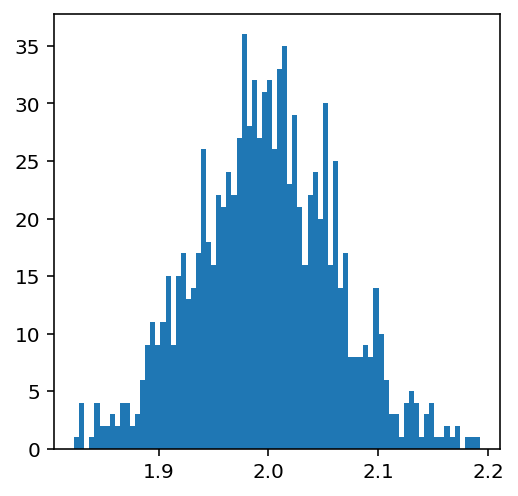

In [7]:
# Using CLT to convert to Normal distribution to estimate the error
# Bootstrap N1 groups of N2 points out of all data points
# Calculate mean for each group
# Estimate error of distribution of means
# Multiply by  sqrt(N2)
N_data = 10**6
data = np.random.exponential(scale=2.0, size=N_data)

N1 = 1000 # N groups
N2 = 1000 # N points in each group
for trial in range(10):
    means = []
    for ii in range(N1):
        yy = np.random.choice(data, replace=True, size=N1)
        means.append(np.mean(yy))

    std_means = np.std(means)
    print(f"np.sqrt(N2)*std_means = {np.sqrt(N2)*std_means:.4f}")
    
plt.rcParams["figure.figsize"] = (4, 4) # (width, height)
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(means, bins=80)
plt.show();

## Trying t-Test on non-Gaussian distributions (exponent)

Suppose we have two data sets A & B
with same number of points.
 
Let's try to do a t-test between them
<br>and compare it to the t-test between two distributions of mean values
<br>(which have Normal distribution because of CLT)

In [32]:
def independent_ttest(data1, data2, alpha=0.05):
    """ calculate t-test for two independent variables """
    # calculate means
    mean1, mean2 = np.mean(data1), np.mean(data2)
    # calculate standard errors
    se1, se2 = stats.sem(data1), stats.sem(data2) # ScyPy
    # standard error on the difference between the samples
    sed = np.sqrt(se1**2.0 + se2**2.0)
    # calculate the t statistic
    t_stat = (mean1 - mean2) / sed
    # degrees of freedom
    df = len(data1) + len(data2) - 2
    # calculate the critical value - a point on test distribution
    # that is compared to the test statistic 
    # to determine whether to reject the null hypothesis. 
    # You reject null hypothesis when abs(t_stat) > cv
    crit_val = stats.t.ppf(1.0 - alpha, df)
    # calculate the p-value
    p_val = (1.0 - stats.t.cdf(abs(t_stat), df)) * 2.0
    # return everything
    return t_stat, df, crit_val, p_val

# ------------------------------------------------
def print_results(t_stat, df, crit_val, p_val, alpha):
    print("-"*40)
    print(f"t_stat       = {t_stat:.4f}")
    print(f"degr.freedom = {df}")
    print(f"crit_val     = {crit_val:.4f}")
    print(f"p_val        = {p_val:.4f}")
    print("\nNull Hypothesis: two means are equal")
    print("reject if abs(t_stat) > crit_val :", end="")
    if abs(t_stat) > crit_val:
        print("  Reject")
    else:
        print("  Accept")
    print("reject if p_val      <= alpha    :", end="")
    if p_val < alpha:
        print("  Reject")
    else:
        print("  Accept")

# ------------------------------------------------
def make_data_means(mydata,N1=1000,N2=1000):
    means = []
    for ii in range(N1):
        yy = np.random.choice(mydata, replace=True, size=N2)
        means.append(np.mean(yy))
    return means

In [66]:
data1 = np.random.exponential(scale=2.0, size=10**6)
means1=make_data_means(data1,N1=1000,N2=1000)
data2 = np.random.exponential(scale=2.005, size=10**6)
means2=make_data_means(data2,N1=1000,N2=1000)

print(f"data1 : {np.mean(data1):.4f} +/- {np.std(data1):.4f}")
print(f"data2 : {np.mean(data2):.4f} +/- {np.std(data2):.4f}")
print(f"means1: {np.mean(means1):.4f} +/- {np.sqrt(N2)*np.std(means1):.4f}")
print(f"means2: {np.mean(means2):.4f} +/- {np.sqrt(N2)*np.std(means2):.4f}")

alpha = 0.05
print("\ndata1, data2")
t_stat, df, crit_val, p_val = independent_ttest(data1, data2, alpha=alpha)
print_results(t_stat, df, crit_val, p_val, alpha)
print("\nmeans1, means2")
t_stat, df, crit_val, p_val = independent_ttest(means1, means2, alpha=alpha)
print_results(t_stat, df, crit_val, p_val, alpha)

data1 : 2.0027 +/- 2.0042
data2 : 2.0047 +/- 2.0030
means1: 1.9992 +/- 2.0323
means2: 2.0046 +/- 2.0065

data1, data2
----------------------------------------
t_stat       = -0.6949
degr.freedom = 1999998
crit_val     = 1.6449
p_val        = 0.4871

Null Hypothesis: two means are equal
reject if abs(t_stat) > crit_val :  Accept
reject if p_val      <= alpha    :  Accept

means1, means2
----------------------------------------
t_stat       = -1.8986
degr.freedom = 1998
crit_val     = 1.6456
p_val        = 0.0578

Null Hypothesis: two means are equal
reject if abs(t_stat) > crit_val :  Reject
reject if p_val      <= alpha    :  Accept


In [61]:
# As you run the above code multiple times, you
# can see how p_value for means changes between runs.
# It may become very different from p_value for data
# arrays - and can negate the results of the t-test!